# 연습문제

## father-son 데이터 셋은 아버지와 아들의 키를 조사한 데이터 셋이다. 아버지의 키가 아들의 키에 영향을 주는지 분석하고 결과를 보고하시오.

In [5]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

# 선형회귀를 위한 참조
from statsmodels.formula.api import ols

# 상관분석을 위한 참조
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [1]:
origin = load_data("father-son")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/father-son.xlsx
[desc] 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)

field    description
-------  -------------------
fheight  아버지의 키(Inches)
sheight  아들의 키(Inches)


===== 데이터 크기 확인 =====
데이터셋 크기: (1078, 2)
열 개수: 2
행 개수: 1078

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB
None


,fheight,sheight
0,65.04851,59.77827
1,63.25094,63.21404
2,64.95532,63.34242
3,65.75250,62.79238
4,61.13723,64.28113


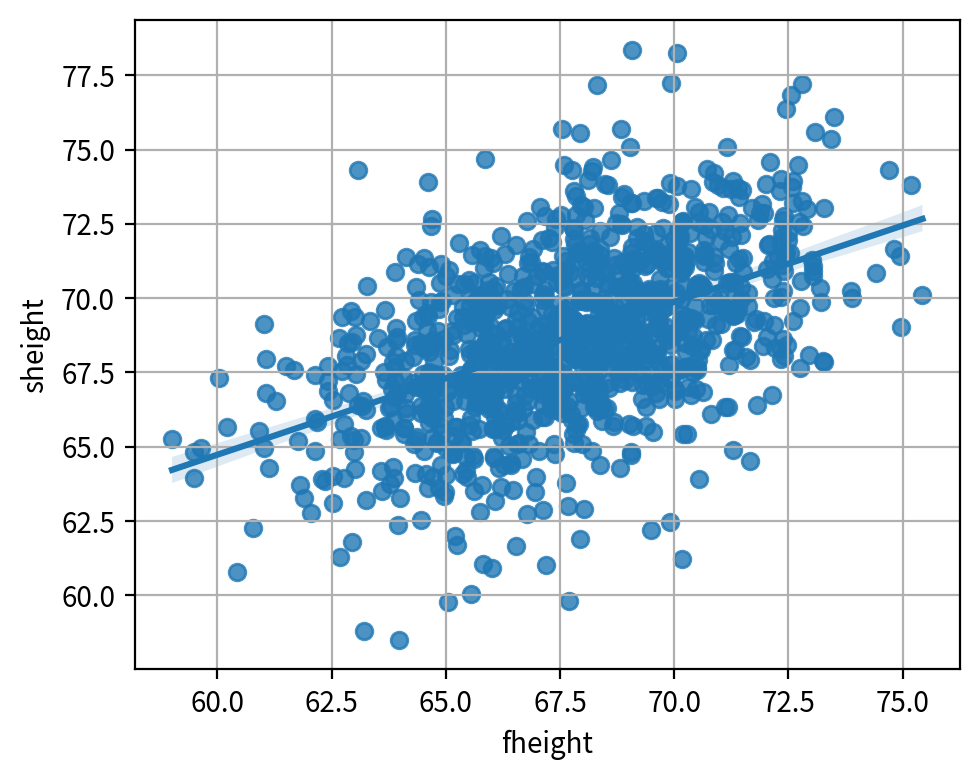

In [3]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.regplot(data=origin, x="fheight", y="sheight")

# 3) 그래프 꾸미기
ax.grid(True)


plt.tight_layout()
plt.show()
plt.close()

Ramsey RESET Test : 선형성 적합 (p-value: 0.9147)


,original_skew,log_skew,outliers(|z|>3)
sheight,-0.036696,-1.401806,10.0
fheight,-0.088268,-1.155431,1.0


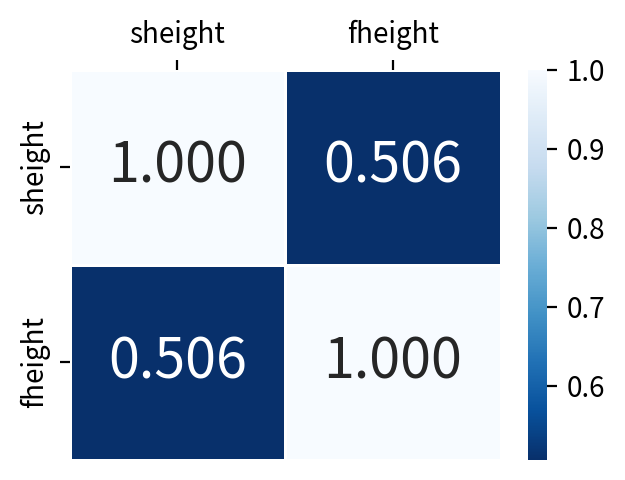

본 분석에서는 sheight과 fheight 간 상관관계를 검토하였다.

데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.

분석 결과, 스피어만 상관계수는 r = 0.506, p = 0.000(으)로 나타나 두 변수 간 양의 단조 관계가 존재함을 확인하였다.


In [4]:
xname = "sheight"
yname = "fheight"

# ---------------------------------
# 선형성 가정 확인 (Ramsey RESET)
# ---------------------------------
x = origin[xname]
y = origin[yname]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

# ---------------------------------
# 이상치와 왜도 검정
# ---------------------------------
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
    }

results_df = DataFrame(results).T
display(results_df)

# 이상치 점검 결과
outlier_flag = (results_df["outliers(|z|>3)"] > 0).any()

# ---------------------------------
# 상관분석 + 보고서 텍스트 생성
# ---------------------------------
report = f"본 분석에서는 {xname}과 {yname} 간 상관관계를 검토하였다.\n\n"

if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearsonr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 상관" if corr > 0 else "음의 상관"
        report += (
            "데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 피어슨 상관계수를 사용하였다.\n\n"
            f"분석 결과, 피어슨 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 통계적으로 유의함을 확인하였다."
        )
else:
    chosen = "spearman"
    corr, pval = spearmanr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 단조" if corr > 0 else "음의 단조"
        report += (
            "데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.\n\n"
            f"분석 결과, 스피어만 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 존재함을 확인하였다."
        )

# ---------------------------------
# 결과 시각화 (상관행렬 히트맵)
# ---------------------------------
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화
width_px = 650  # 그래프 가로 크기
height_px = 500  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()  # x축의 변수 이름을 상단으로 이동

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

# ---------------------------------
# 결과 보고 출력
# ---------------------------------
print(report)

In [13]:
x = origin[["fheight"]]
x

,fheight
0,65.04851
1,63.25094
2,64.95532
3,65.75250
4,61.13723
...,...
1073,66.99681
1074,71.33181
1075,71.78314
1076,70.73837


In [14]:
y = origin["sheight"]
y

0       59.77827
1       63.21404
2       63.34242
3       62.79238
4       64.28113
          ...   
1073    70.75232
1074    68.26774
1075    69.30589
1076    69.30199
1077    67.01500
Name: sheight, Length: 1078, dtype: float64

In [15]:
X = sm.add_constant(x)
X.head()

,const,fheight
0,1.0,65.04851
1,1.0,63.25094
2,1.0,64.95532
3,1.0,65.75250
4,1.0,61.13723


In [16]:
model = sm.OLS(y, X)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           1.12e-69
Time:                        12:12:16   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

sheight(아들키)를 종속변수로, fheight(아빠키)를 독립변수로 한 단순회귀분석 결과, 모형은 통계적으로 유의하였다.
F(1, 1076) = 361.2, p < 0.001, R² = 0.251.
즉, 아빠키는 아들 키의 약 25.1%를 설명하는 것으로 나타났다.

In [11]:
df = origin.copy()
df["y_pred"] = fit.predict(X)
df.head()

,fheight,sheight,y_pred
0,65.04851,59.77827,67.327591
1,63.25094,63.21404,66.403472
2,64.95532,63.34242,67.279682
3,65.75250,62.79238,67.689507
4,61.13723,64.28113,65.316829


In [17]:
df_melt = df.melt(
    id_vars="fheight",
    value_vars=["sheight", "y_pred"],
    var_name="variable",
    value_name="value",
)
df_melt.head()

,fheight,variable,value
0,65.04851,sheight,59.77827
1,63.25094,sheight,63.21404
2,64.95532,sheight,63.34242
3,65.75250,sheight,62.79238
4,61.13723,sheight,64.28113


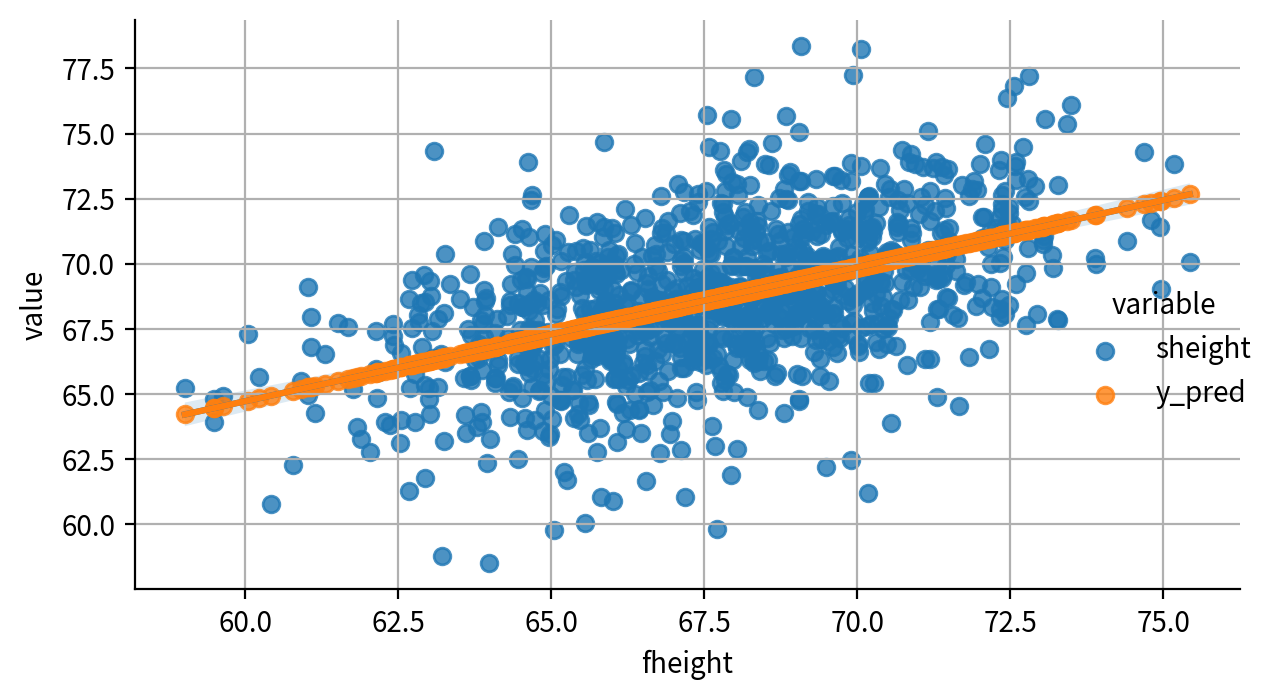

In [19]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
# 2) LM Plot 그리기
g = sb.lmplot(data=df_melt, x="fheight", y="value", hue="variable")
g.fig.set_dpi(my_dpi)
g.fig.set_figwidth(figsize[0])
g.fig.set_figheight(figsize[1])
plt.grid()
# 3) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료